# Lab 4 — Cluster Metrics

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

Evaluate K-Means segmentation quality with three standard internal metrics.

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Why this matters <!-- cisco-doc-enrich-2026 -->

Visual inspection lies on 6+ dimensions. **Silhouette, Davies–Bouldin, Calinski–Harabasz**
score cluster quality numerically — compare k or algorithm choices objectively.

```
high silhouette  -->  tight, well-separated clusters
low DB index       -->  better (compact vs separated)
```


## Setup baseline model

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

Groupby complete — compare categories in the table above.


**Step 4** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [4]:
X_scaled = StandardScaler().fit_transform(features[FEATURE_COLUMNS])
k = 4
labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
print(f"symbols: {len(features)}, k: {k}")

symbols: 25, k: 4


## Compute silhouette, DB, and CH

In [5]:
sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Lab 4 — Cluster metrics")
print(f"k: {k}")
print(f"silhouette score: {sil:.4f}  (higher is better, max 1)")
print(f"Davies-Bouldin index: {db:.4f}  (lower is better)")
print(f"Calinski-Harabasz score: {ch:.4f}  (higher is better)")

Lab 4 — Cluster metrics
k: 4
silhouette score: 0.2414  (higher is better, max 1)
Davies-Bouldin index: 1.0659  (lower is better)
Calinski-Harabasz score: 8.2627  (higher is better)


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [6]:
metrics_df = pd.DataFrame({
    "metric": ["silhouette", "davies_bouldin", "calinski_harabasz"],
    "value": [sil, db, ch],
    "direction": ["higher better", "lower better", "higher better"],
})
display(metrics_df.round(4))

,metric,value,direction
0,silhouette,0.2414,higher better
1,davies_bouldin,1.0659,lower better
2,calinski_harabasz,8.2627,higher better


## Per-sample silhouette details

In [7]:
from sklearn.metrics import silhouette_samples

sample_scores = silhouette_samples(X_scaled, labels)
features = features.copy()
features["cluster"] = labels
features["silhouette"] = sample_scores.round(3)

display(
    features[["symbol", "cluster", "silhouette"]]
    .sort_values("silhouette")
    .head(5)
)


,symbol,cluster,silhouette
9,JPM,2,-0.026
5,GOOGL,2,-0.015
16,PEP,3,0.000
12,META,2,0.041
24,XOM,2,0.055


## Compare metric values for k=3 vs k=4

In [8]:
rows = []
for k_try in [3, 4]:
    lbl = KMeans(n_clusters=k_try, random_state=42, n_init=10).fit_predict(X_scaled)
    rows.append({
        "k": k_try,
        "silhouette": silhouette_score(X_scaled, lbl),
        "davies_bouldin": davies_bouldin_score(X_scaled, lbl),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, lbl),
    })

compare_k = pd.DataFrame(rows)
display(compare_k.round(4))


,k,silhouette,davies_bouldin,calinski_harabasz
0,3,0.2208,1.2378,8.2392
1,4,0.2414,1.0659,8.2627


## Visualize normalized metrics

C:\Users\PC\AppData\Local\Temp\ipykernel_25448\1516924449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="metric", y="display_value", ax=ax, palette="Set2")


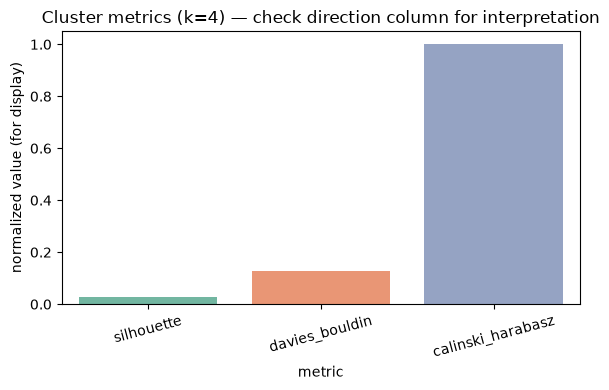

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df = metrics_df.copy()
plot_df["display_value"] = plot_df["value"] / plot_df["value"].max()
sns.barplot(data=plot_df, x="metric", y="display_value", ax=ax, palette="Set2")
ax.set_ylabel("normalized value (for display)")
ax.set_title(f"Cluster metrics (k={k}) — check direction column for interpretation")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Metric interpretation prompt 1

Show metrics table sorted by absolute value.

In [10]:
display(metrics_df.sort_values('value', ascending=False).round(4))

,metric,value,direction
2,calinski_harabasz,8.2627,higher better
1,davies_bouldin,1.0659,lower better
0,silhouette,0.2414,higher better


### Metric interpretation prompt 2

Compute silhouette summary by cluster.

In [11]:
display(features.groupby('cluster')['silhouette'].agg(['mean','min','max']).round(3))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

,mean,min,max
cluster,,,
0,0.284,0.096,0.480
1,0.314,0.136,0.433
2,0.134,-0.026,0.332
3,0.000,0.000,0.000


Groupby complete — compare categories in the table above.


### Metric interpretation prompt 3

Count negative silhouette points.

In [12]:
print(int((features['silhouette'] < 0).sum()))

2


### Metric interpretation prompt 4

List symbols with lowest silhouette.

In [13]:
display(features.nsmallest(5, 'silhouette')[['symbol','cluster','silhouette']])

,symbol,cluster,silhouette
9,JPM,2,-0.026
5,GOOGL,2,-0.015
16,PEP,3,0.000
12,META,2,0.041
24,XOM,2,0.055


### Metric interpretation prompt 5

List symbols with highest silhouette.

In [14]:
display(features.nlargest(5, 'silhouette')[['symbol','cluster','silhouette']])

,symbol,cluster,silhouette
21,V,0,0.480
6,HD,1,0.433
2,BAC,1,0.418
19,TSLA,0,0.376
7,INTC,1,0.368


### Metric interpretation prompt 6

Compare k=3 metric row.

In [15]:
display(compare_k.loc[compare_k['k']==3].round(4))

,k,silhouette,davies_bouldin,calinski_harabasz
0,3,0.2208,1.2378,8.2392


### Metric interpretation prompt 7

Compare k=4 metric row.

In [16]:
display(compare_k.loc[compare_k['k']==4].round(4))

,k,silhouette,davies_bouldin,calinski_harabasz
1,4,0.2414,1.0659,8.2627


### Metric interpretation prompt 8

Compute custom score: silhouette / DB.

In [17]:
print(round(float(sil / db), 4))

0.2265


### Metric interpretation prompt 9

Compute ratio CH/DB.

In [18]:
print(round(float(ch / db), 4))

7.7518


### Metric interpretation prompt 10

Display per-cluster counts.

In [19]:
print(features['cluster'].value_counts().sort_index().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{0: 8, 1: 9, 2: 7, 3: 1}
Value counts — long tail categories may be omitted.


### Metric interpretation prompt 11

Histogram of silhouette scores.

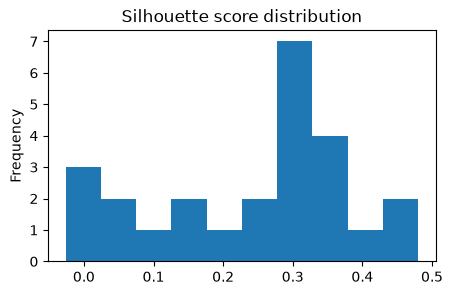

In [20]:
ax = features['silhouette'].plot(kind='hist', bins=10, figsize=(5,3)); ax.set_title('Silhouette score distribution');

### Metric interpretation prompt 12

Boxplot silhouette by cluster.

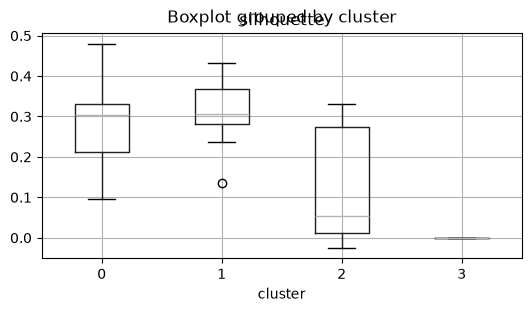

In [21]:
ax = features.boxplot(column='silhouette', by='cluster', figsize=(6,3));

### Metric interpretation prompt 13

Summarize interpretation sentence.

In [22]:
print('k=4 provides moderate separation with some overlap and one weaker cluster boundary.')

k=4 provides moderate separation with some overlap and one weaker cluster boundary.


### Metric interpretation prompt 14

Check metric directions table.

In [23]:
print(metrics_df[['metric','direction']].to_dict(orient='records'))

[{'metric': 'silhouette', 'direction': 'higher better'}, {'metric': 'davies_bouldin', 'direction': 'lower better'}, {'metric': 'calinski_harabasz', 'direction': 'higher better'}]


### Metric interpretation prompt 15

Create compact dict snapshot.

In [24]:
print({'k': k, 'sil': round(sil,4), 'db': round(db,4), 'ch': round(ch,4)})

{'k': 4, 'sil': 0.2414, 'db': 1.0659, 'ch': 8.2627}


### Metric interpretation prompt 16

Difference between k=3 and k=4 silhouette.

In [25]:
print(round(float(compare_k.loc[compare_k['k']==4, 'silhouette'].iloc[0] - compare_k.loc[compare_k['k']==3, 'silhouette'].iloc[0]), 4))

0.0206


### Metric interpretation prompt 17

Difference between k=3 and k=4 DB.

In [26]:
print(round(float(compare_k.loc[compare_k['k']==4, 'davies_bouldin'].iloc[0] - compare_k.loc[compare_k['k']==3, 'davies_bouldin'].iloc[0]), 4))

-0.1718


### Metric interpretation prompt 18

Difference between k=3 and k=4 CH.

In [27]:
print(round(float(compare_k.loc[compare_k['k']==4, 'calinski_harabasz'].iloc[0] - compare_k.loc[compare_k['k']==3, 'calinski_harabasz'].iloc[0]), 4))

0.0235


### Metric interpretation prompt 19

Bridge to visualization lab.

In [28]:
print('Next notebook visualizes K-Means and DBSCAN outputs side-by-side.')

Next notebook visualizes K-Means and DBSCAN outputs side-by-side.


### Metric interpretation prompt 20

Confirm expected symbol count.

In [29]:
print(len(features), features['symbol'].nunique())

25 25


### Lab 4 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [30]:
print("Lab 4 recap step 1: completed")

Lab 4 recap step 1: completed


### Lab 4 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [31]:
print("Lab 4 recap step 2: completed")

Lab 4 recap step 2: completed


### Lab 4 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 4 recap step 3: completed")

Lab 4 recap step 3: completed


### Lab 4 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 4 recap step 4: completed")

Lab 4 recap step 4: completed


### Lab 4 quick recap 5

Pause and summarize one takeaway from the previous cell before moving on.

In [34]:
print("Lab 4 recap step 5: completed")

Lab 4 recap step 5: completed

## Final checkpoint

In [35]:
assert k == 4
assert abs(sil - 0.2414) < 0.05
assert abs(db - 1.0659) < 0.1
assert abs(ch - 8.2627) < 1.0
print("Numbers match — you're good.")



Numbers match — you're good.

## Reflection

Which metric would you prioritize for dense, noisy financial features?